<a href="https://colab.research.google.com/github/nehalnady/DM_Project/blob/main/DM_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression


df = pd.read_csv('/content/vehicles.csv', engine='python', on_bad_lines='warn')
print(df.head())
print("cloumns: ", df.columns)
df.columns = df.columns.str.strip().str.lower()

           id                                                url  \
0  7222695916  https://prescott.craigslist.org/cto/d/prescott...   
1  7218891961  https://fayar.craigslist.org/ctd/d/bentonville...   
2  7221797935  https://keys.craigslist.org/cto/d/summerland-k...   
3  7222270760  https://worcester.craigslist.org/cto/d/west-br...   
4  7210384030  https://greensboro.craigslist.org/cto/d/trinit...   

                   region                         region_url  price  year  \
0                prescott    https://prescott.craigslist.org   6000   NaN   
1            fayetteville       https://fayar.craigslist.org  11900   NaN   
2            florida keys        https://keys.craigslist.org  21000   NaN   
3  worcester / central MA   https://worcester.craigslist.org   1500   NaN   
4              greensboro  https://greensboro.craigslist.org   4900   NaN   

  manufacturer model condition cylinders  ... size  type paint_color  \
0          NaN   NaN       NaN       NaN  ...  NaN   NaN

In [2]:


# # Clean column names
# df.columns = df.columns.str.strip().str.lower()

# print("Columns:", df.columns.tolist())

# # =========================
# # 1. Remove duplicates
# # =========================
# df.drop_duplicates(inplace=True)

# # =========================
# # 2. Drop useless columns EARLY
# # =========================
# drop_cols = [
#     "id", "url", "region_url", "image_url",
#     "description", "vin", "posting_date"
# ]
# df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# # =========================
# # 3. Handle numeric columns
# # =========================
# numeric_cols = ["year", "odometer", "price", "lat", "long"]

# for col in numeric_cols:
#     if col in df.columns:
#         df[col] = pd.to_numeric(df[col], errors='coerce')
#         df[col].fillna(df[col].median(), inplace=True)

# # =========================
# # 4. Outlier capping
# # =========================
# for col in ["price", "odometer", "year"]:
#     if col in df.columns:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# # =========================
# # 5. Drop high-cardinality columns
# # =========================
# high_card_cols = ["model", "region"]
# df.drop(columns=[c for c in high_card_cols if c in df.columns], inplace=True)

# # =========================
# # 6. One-Hot Encoding ONLY
# # =========================
# df = pd.get_dummies(df, drop_first=True)

# print("Shape after encoding:", df.shape)

# # =========================
# # 7. FINAL NaN cleanup (CRITICAL ✅)
# # =========================
# df.fillna(df.median(numeric_only=True), inplace=True)

# # =========================
# # 8. Feature / target split
# # =========================
# X = df.drop("price", axis=1)
# y = df["price"]

# # =========================
# # 9. Scaling
# # =========================
# scaler = StandardScaler()
# X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# # Safety check (IMPORTANT)
# print("Remaining NaNs:", X_scaled.isnull().sum().sum())

# # =========================
# # 10. Feature selection
# # =========================
# selector = SelectKBest(score_func=f_regression, k=min(10, X.shape[1]))
# X_selected = selector.fit_transform(X_scaled, y)

# selected_features = X.columns[selector.get_support()]
# print("\nSelected features:", list(selected_features))

In [3]:
# ── B1. Remove duplicates ────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  [1] Duplicates removed : {before - len(df)}  →  {len(df)} rows remain")

# ── B2. Drop irrelevant or high-cardinality columns ───────────
# Adapt drop_cols for the 'vehicles.csv' dataset.
# Using columns identified as useless or high-cardinality in the original context (e.g., cell IKkTHKnvs0_L)
drop_cols = [
    "id", "url", "region_url", "image_url", "description", "vin", "posting_date", # From previous (commented) cell's approach
    "county", # This column is almost entirely NaN based on `missing` variable in kernel state
    "model", "region" # High cardinality, from previous (commented) cell's approach
]
# Ensure only existing columns are dropped
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
print(f"  [2] Dropped columns: {', '.join([col for col in drop_cols if col in df.columns])}")

# ── B3. Handle numeric columns: type conversion and initial NaN imputation ──────────────────────
numeric_cols = ["year", "odometer", "price", "lat", "long"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Impute NaNs with median for numeric columns
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
print("  [3] Processed numeric columns (type converted & NaNs filled with median):", ", ".join([c for c in numeric_cols if c in df.columns]))

# ── B4. Outlier detection & capping (IQR) ───────────────────────────
outlier_targets = ["price", "odometer", "year"] # Use actual numeric columns
print(f"\n  [4] Outlier detection (IQR):")
for col in outlier_targets:
    if col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lo, hi)
        print(f"    {col:20s} : {n_out:4d} outliers capped")

# ── B5. Feature engineering: car age ────────────────────────
current_year = 2024
if "year" in df.columns:
    df["car_age"] = current_year - df["year"]
    df.drop(columns=["year"], inplace=True)
    print(f"\n  [5] Created 'car_age' from 'year'")
else:
    print(f"\n  [5] 'year' column not found, 'car_age' not created.")

# ── B6. Handle missing values (categorical) and Label Encode ────────────────────────────────
# Identify all remaining categorical columns (object type)
print(f"\n  [6] Missing values before categorical imputation and encoding:")
missing_before_cat_impute = df.isnull().sum()
if missing_before_cat_impute[missing_before_cat_impute > 0].empty:
    print("    No missing categorical values.")
else:
    print(missing_before_cat_impute[missing_before_cat_impute > 0].to_string())

le = LabelEncoder()
categorical_cols_to_encode = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols_to_encode:
    # Fill NaNs with mode before encoding
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)
    df[col] = le.fit_transform(df[col].astype(str))
print("  → Categorical NaNs filled with mode & Label-encoded :", ', '.join(categorical_cols_to_encode))
print(f"  Shape after encoding : {df.shape}")

# ── B7. Feature / target split ──────────────────────────────
target_col = "price" # 'selling_price' from original cell is 'price' in 'vehicles.csv'

if target_col in df.columns:
    X = df.drop(columns=[target_col])
    y = df[target_col]
    print(f"\n  [7] Feature/target split: X (features), y (target='{target_col}')")
else:
    X = pd.DataFrame() # Initialize empty in case target not found
    y = pd.Series()
    print(f"\n  [7] Target column '{target_col}' not found. Cannot perform feature/target split.")

# ── B8. Feature scaling ─────────────────────────────────────
# Final safety fill — catch any NaNs that survived, especially important for X before scaling
if not X.empty:
    if X.isnull().sum().sum() > 0:
        print("\n  [8] Warning: NaNs found in X before scaling. Imputing with median.")
        X.fillna(X.median(numeric_only=True), inplace=True)

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    print("  [8] Features scaled using StandardScaler.")
else:
    X_scaled = pd.DataFrame()
    print("  [8] Feature scaling skipped as X is empty.")

# ── B9. Feature selection (SelectKBest, top-10 or all) ──────
if not X_scaled.empty and not y.empty:
    k = min(10, X_scaled.shape[1])
    selector = SelectKBest(score_func=f_regression, k=k)

    # Re-check for NaNs before fit_transform (defense-in-depth)
    if X_scaled.isnull().sum().sum() > 0:
        print("\n  [9] Warning: NaNs found in X_scaled before feature selection. Imputing with median.")
        X_scaled.fillna(X_scaled.median(numeric_only=True), inplace=True)

    X_selected = selector.fit_transform(X_scaled, y)
    selected_features = X.columns[selector.get_support()]

    print(f"\n  [9] Feature selection — kept {k} / {X_scaled.shape[1]} features")
    print(f"   Selected : {list(selected_features)}")
else:
    print("\n  [9] Feature selection skipped due to empty X_scaled or y.")


  [1] Duplicates removed : 0  →  147323 rows remain
  [2] Dropped columns: 
  [3] Processed numeric columns (type converted & NaNs filled with median): year, odometer, price, lat, long

  [4] Outlier detection (IQR):
    price                : 3313 outliers capped
    odometer             : 1800 outliers capped
    year                 : 5746 outliers capped

  [5] Created 'car_age' from 'year'

  [6] Missing values before categorical imputation and encoding:
manufacturer      6406
condition        59757
cylinders        60412
fuel               889
title_status      2873
transmission       798
drive            45432
size            105107
type             29382
paint_color      43164
  → Categorical NaNs filled with mode & Label-encoded : manufacturer, condition, cylinders, fuel, title_status, transmission, drive, size, type, paint_color, state
  Shape after encoding : (147323, 16)

  [7] Feature/target split: X (features), y (target='price')
  [8] Features scaled using StandardScaler

In [4]:
# train and test splitting

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.20, random_state=42)
print(f"  Train : {X_train.shape[0]} samples   Test : {X_test.shape[0]} samples")
model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.08, max_depth=5, random_state=42,subsample=0.8)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=kf, scoring="neg_mean_squared_error"))
print(f"  5-fold CV  R²   : {cv_r2.round(4)}  →  mean = {cv_r2.mean():.4f}")
print(f"  5-fold CV  RMSE : {cv_rmse.round(0)}  →  mean = {cv_rmse.mean():.0f}")
model.fit(X_train, y_train)

  Train : 117858 samples   Test : 29465 samples
  5-fold CV  R²   : [0.593  0.5911 0.5993 0.594  0.587 ]  →  mean = 0.5929
  5-fold CV  RMSE : [8990. 8914. 8876. 8987. 9119.]  →  mean = 8977


GradientBoostingRegressor(learning_rate=0.08, max_depth=5, n_estimators=300,
                          random_state=42, subsample=0.8)

In [5]:
# the prdiction

sample_indices = np.random.choice(len(X_test), 5, replace=False)
new_samples = X_test[sample_indices]
new_preds   = model.predict(new_samples)
new_actual  = y_test.values[sample_indices]
print(f"  {'Car':>5}  {'Predicted Price (₹)':>22}  {'Actual Price (₹)':>20}  {'Error %':>8}")
print("  " + "-" * 62)
for i, (pred, actual) in enumerate(zip(new_preds, new_actual)):
    err = abs(pred - actual) / actual * 100
    print(f"  {i+1:>5}  {pred:>22,.0f}  {actual:>20,.0f}  {err:>7.1f}%")

    Car     Predicted Price (₹)      Actual Price (₹)   Error %
  --------------------------------------------------------------
      1                   6,647                17,000     60.9%
      2                  26,180                29,990     12.7%
      3                  21,559                22,795      5.4%
      4                  18,434                23,985     23.1%
      5                  28,899                43,000     32.8%


Mounted at /content/drive
  MSE   (Mean Squared Error)  :        81,369,629.62
  RMSE  (Root MSE)            :             9,020.51
  MAE   (Mean Abs. Error)     :             5,931.14
  R²    Score                 :               0.5941


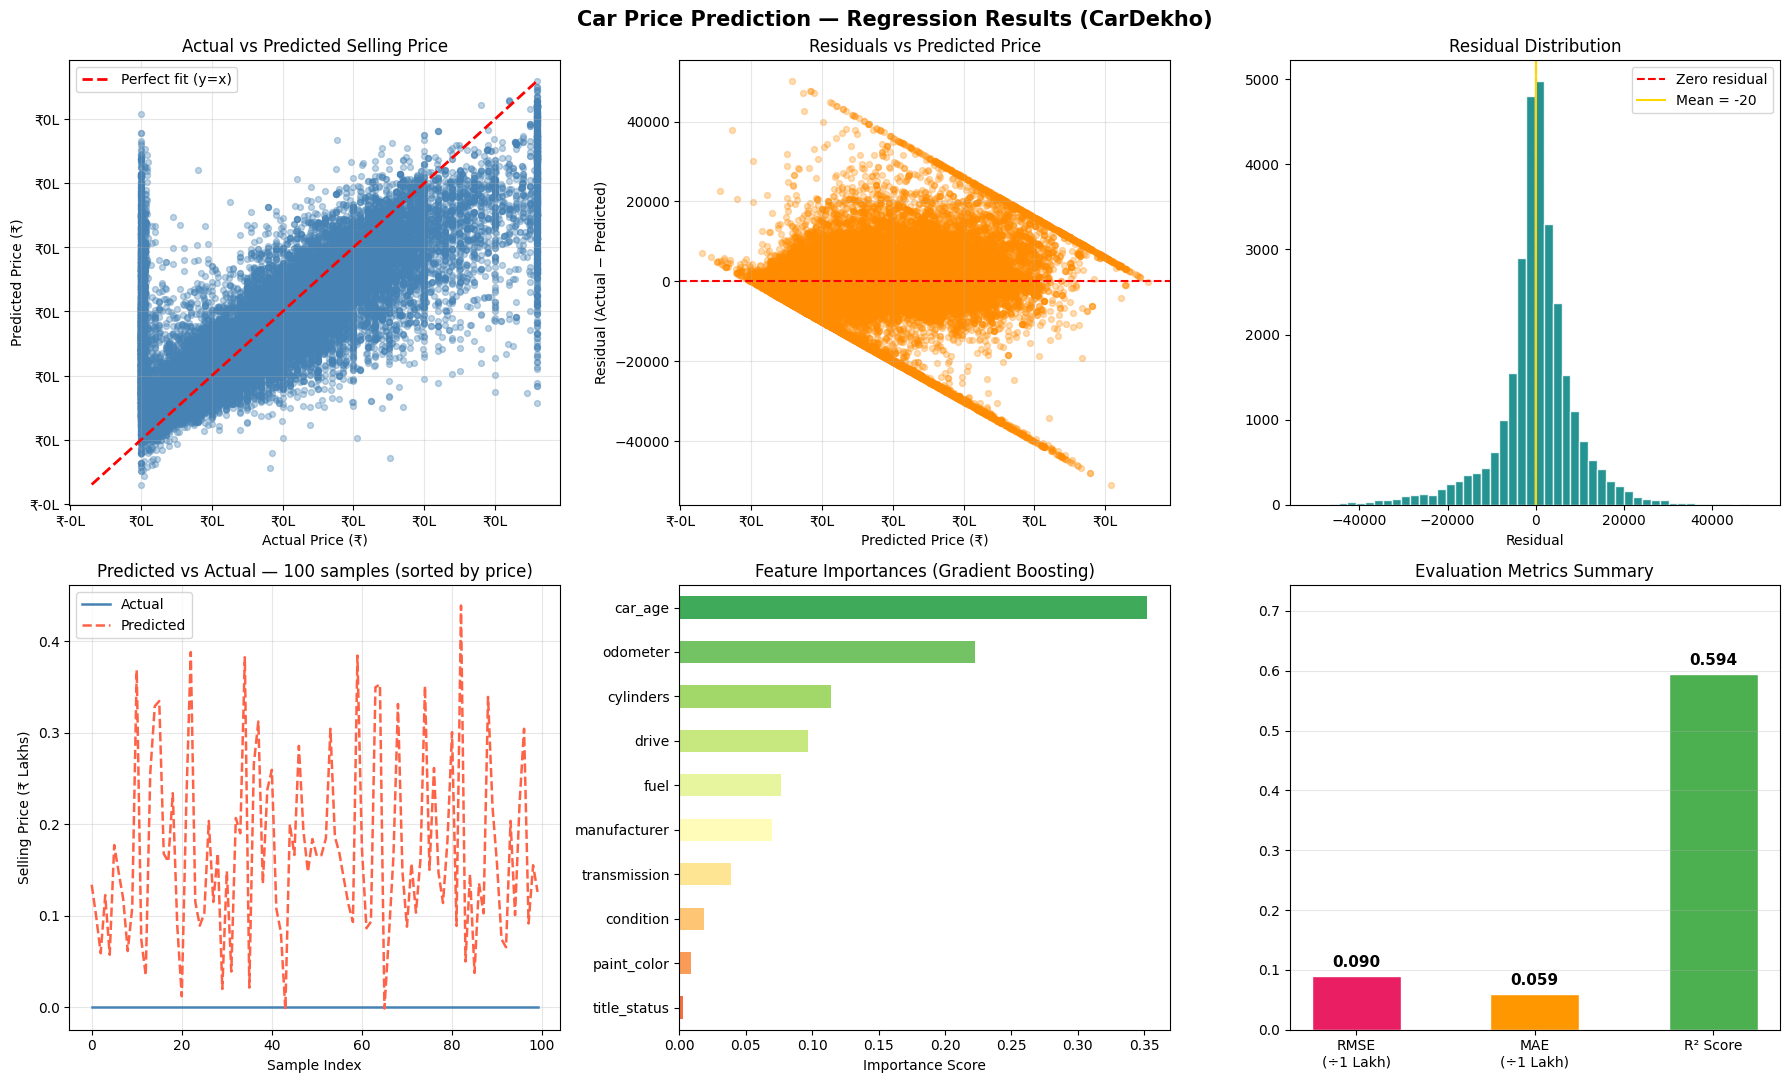


✔  Visualization saved → /content/drive/MyDrive/task2_regression_problem.png

  DONE — All requirements (A–G) completed successfully.


In [11]:
from google.colab import drive
drive.mount('/content/drive')

# Evaluation

y_pred = model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae  = mean_absolute_error(y_test, y_pred)

r2   = r2_score(y_test, y_pred)

print(f"  MSE   (Mean Squared Error)  : {mse:>20,.2f}")
print(f"  RMSE  (Root MSE)            : {rmse:>20,.2f}")
print(f"  MAE   (Mean Abs. Error)     : {mae:>20,.2f}")
print(f"  R²    Score                 : {r2:>20.4f}")




#visulizations

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Car Price Prediction — Regression Results (CarDekho)", fontsize=15, fontweight="bold")
# ── 1. Actual vs Predicted scatter ───────────────────────────
axes[0, 0].scatter(y_test, y_pred, alpha=0.35, color="steelblue", s=18)
lim_lo = min(y_test.min(), y_pred.min())
lim_hi = max(y_test.max(), y_pred.max())
axes[0, 0].plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", lw=2, label="Perfect fit (y=x)")
axes[0, 0].set_title("Actual vs Predicted Selling Price")
axes[0, 0].set_xlabel("Actual Price (₹)")
axes[0, 0].set_ylabel("Predicted Price (₹)")

axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].yaxis.set_major_formatter( plt.FuncFormatter(lambda v, _: f"₹{v/1e5:.0f}L"))

axes[0, 0].xaxis.set_major_formatter( plt.FuncFormatter(lambda v, _: f"₹{v/1e5:.0f}L"))

# ── 2. Residual plot ─────────────────────────────────────────

residuals = y_test.values - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.3, color="darkorange", s=18)
axes[0, 1].axhline(0, color="red", lw=1.5, linestyle="--")
axes[0, 1].set_title("Residuals vs Predicted Price")
axes[0, 1].set_xlabel("Predicted Price (₹)")
axes[0, 1].set_ylabel("Residual (Actual − Predicted)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].xaxis.set_major_formatter( plt.FuncFormatter(lambda v, _: f"₹{v/1e5:.0f}L"))

# ── 3. Residual distribution ─────────────────────────────────

axes[0, 2].hist(residuals, bins=50, color="teal", edgecolor="white", alpha=0.85)
axes[0, 2].axvline(0, color="red", linestyle="--", lw=1.5, label="Zero residual")
axes[0, 2].axvline(np.mean(residuals), color="gold", linestyle="-",
                    lw=1.5, label=f"Mean = {np.mean(residuals):,.0f}")
axes[0, 2].set_title("Residual Distribution")
axes[0, 2].set_xlabel("Residual"); axes[0, 2].legend()

# ── 4. Predicted vs Actual — sorted line chart (100 samples) ─

sort_idx = np.argsort(y_test.values)[:100]
axes[1, 0].plot(range(100), y_test.values[sort_idx] / 1e5, label="Actual",    color="steelblue", lw=1.8)
axes[1, 0].plot(range(100), y_pred[sort_idx] / 1e5,
                label="Predicted", color="tomato",    lw=1.8, linestyle="--")
axes[1, 0].set_title("Predicted vs Actual — 100 samples (sorted by price)")
axes[1, 0].set_xlabel("Sample Index")
axes[1, 0].set_ylabel("Selling Price (₹ Lakhs)")
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# ── 5. Feature importances ───────────────────────────────────

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=selected_features).sort_values()

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(feat_imp)))
feat_imp.plot(kind="barh", ax=axes[1, 1], color=colors)
axes[1, 1].set_title("Feature Importances (Gradient Boosting)")
axes[1, 1].set_xlabel("Importance Score")

# ── 6. Metrics summary ───────────────────────────────────────

metric_labels = ["RMSE\n(÷1 Lakh)", "MAE\n(÷1 Lakh)", "R² Score"]
metric_values = [rmse / 1e5, mae / 1e5, r2]
bar_colors    = ["#E91E63", "#FF9800", "#4CAF50"]
bars = axes[1, 2].bar(metric_labels, metric_values, color=bar_colors,
                       edgecolor="white", width=0.5)
for bar, val in zip(bars, metric_values):
    axes[1, 2].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1, 2].set_title("Evaluation Metrics Summary")
axes[1, 2].set_ylim(0, max(metric_values) * 1.25)
axes[1, 2].grid(axis="y", alpha=0.3)
plt.tight_layout()
out_path = "/content/drive/MyDrive/task2_regression_problem.png"
plt.savefig("/content/drive/MyDrive/task2_regression_problem.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✔  Visualization saved → {out_path}")
print("\n" + "=" * 65)
print("  DONE — All requirements (A–G) completed successfully.")
print("=" * 65)